In [1]:
import sys
print(sys.executable)

C:\Users\HP\.conda\envs\env\python.exe


In [22]:
from pathlib import Path
DATA_DIR = Path("../data")
easy_ham = DATA_DIR / "20030228_easy_ham" / "easy_ham"
easy_ham2 = DATA_DIR / "20030228_easy_ham_2" / "easy_ham_2"
hard_ham = DATA_DIR / "20030228_hard_ham" / "hard_ham"

spam = DATA_DIR / "20030228_spam" / "spam"
spam2 = DATA_DIR / "20030228_spam_2" / "spam_2"

In [23]:
#this is an function to load Emails
def load_emails(data):
    emails = []
    for file in data.iterdir():
        if file.name.startswith("."):
            continue
        with open(file,"r", encoding="latin1") as f:
            email_text = f.read()
        emails.append(email_text)
    return emails

In [25]:
#load all the emails 
ham_easy=load_emails(easy_ham)
ham_easy2=load_emails(easy_ham2)
ham_hard=load_emails(hard_ham)
spam_1=load_emails(spam)
spam_2=load_emails(spam2)

#combine them 
ham_emails=ham_easy+ham_easy2+ham_hard
spam_emails=spam_1+spam_2

print("ham emails:",len(ham_emails))
print("spam emails:",len(spam_emails))

ham emails: 4153
spam emails: 1899


In [28]:
print(ham_emails[0])
print(spam_emails[0])
print("Total emails:", len(ham_emails) + len(spam_emails))

From exmh-workers-admin@redhat.com  Thu Aug 22 12:36:23 2002
Return-Path: <exmh-workers-admin@spamassassin.taint.org>
Delivered-To: zzzz@localhost.netnoteinc.com
Received: from localhost (localhost [127.0.0.1])
	by phobos.labs.netnoteinc.com (Postfix) with ESMTP id D03E543C36
	for <zzzz@localhost>; Thu, 22 Aug 2002 07:36:16 -0400 (EDT)
Received: from phobos [127.0.0.1]
	by localhost with IMAP (fetchmail-5.9.0)
	for zzzz@localhost (single-drop); Thu, 22 Aug 2002 12:36:16 +0100 (IST)
Received: from listman.spamassassin.taint.org (listman.spamassassin.taint.org [66.187.233.211]) by
    dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g7MBYrZ04811 for
    <zzzz-exmh@spamassassin.taint.org>; Thu, 22 Aug 2002 12:34:53 +0100
Received: from listman.spamassassin.taint.org (localhost.localdomain [127.0.0.1]) by
    listman.redhat.com (Postfix) with ESMTP id 8386540858; Thu, 22 Aug 2002
    07:35:02 -0400 (EDT)
Delivered-To: exmh-workers@listman.spamassassin.taint.org
Received: from int-mx1.corp

In [33]:
X = ham_emails + spam_emails
y=[0]*len(ham_emails) + [1]*len(spam_emails)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
print(X_train[0])

From VWcmE8@sky.seed.net.tw  Tue Aug  6 12:52:21 2002
Return-Path: <VWcmE8@sky.seed.net.tw>
Delivered-To: yyyy@localhost.netnoteinc.com
Received: from localhost (localhost [127.0.0.1])
	by phobos.labs.netnoteinc.com (Postfix) with ESMTP id AF377441F1
	for <jm@localhost>; Tue,  6 Aug 2002 07:18:09 -0400 (EDT)
Received: from phobos [127.0.0.1]
	by localhost with IMAP (fetchmail-5.9.0)
	for jm@localhost (single-drop); Tue, 06 Aug 2002 12:18:09 +0100 (IST)
Received: from w8k2x7 (5.c170.ethome.net.tw [202.178.170.5]) by
    dogma.slashnull.org (8.11.6/8.11.6) with SMTP id g73JYOv24787 for
    <jm@jmason.org>; Sat, 3 Aug 2002 20:34:27 +0100
Date: Sat, 3 Aug 2002 20:34:27 +0100
Received: from saturn by pchome.com.tw with SMTP id 0AQfX2H0zhc8wecYw;
    Sun, 04 Aug 2002 03:32:59 +0800
Message-Id: <N0LVy9rzPr@iris.seed.net.tw>
From: 8@ms34.url.com.tw
To: 1@dogma.slashnull.org
Subject: =?big5?Q?=B3=D0=B7~=C2=E0=B7~=A4u=C5=AA=B7s=A6=E6=B7~=B6W=B0=D3=B3s=C2=EA=A5[=B7=F9?=
MIME-Version: 1.0
X-Mailer

In [38]:
#function to clean the data  for lowercase replace urls replace numbers remove punctuation remove extra spaces by using regular expression 

import re
import string

def preprocess_email(text):
    text=text.lower()
    text=re.sub(r"https?://\S+","url",text)
    text=re.sub(r"\d+","NUMBER",text)
    text=text.translate(str.maketrans("","",string.punctuation))
    text=" ".join(text.split())
    return text

In [39]:
sample = X_train[0]

print("original:\n")
print(sample)

print("\n" + "="*60 + "\n")

print("processed:\n")
print(preprocess_email(sample))

original:

From VWcmE8@sky.seed.net.tw  Tue Aug  6 12:52:21 2002
Return-Path: <VWcmE8@sky.seed.net.tw>
Delivered-To: yyyy@localhost.netnoteinc.com
Received: from localhost (localhost [127.0.0.1])
	by phobos.labs.netnoteinc.com (Postfix) with ESMTP id AF377441F1
	for <jm@localhost>; Tue,  6 Aug 2002 07:18:09 -0400 (EDT)
Received: from phobos [127.0.0.1]
	by localhost with IMAP (fetchmail-5.9.0)
	for jm@localhost (single-drop); Tue, 06 Aug 2002 12:18:09 +0100 (IST)
Received: from w8k2x7 (5.c170.ethome.net.tw [202.178.170.5]) by
    dogma.slashnull.org (8.11.6/8.11.6) with SMTP id g73JYOv24787 for
    <jm@jmason.org>; Sat, 3 Aug 2002 20:34:27 +0100
Date: Sat, 3 Aug 2002 20:34:27 +0100
Received: from saturn by pchome.com.tw with SMTP id 0AQfX2H0zhc8wecYw;
    Sun, 04 Aug 2002 03:32:59 +0800
Message-Id: <N0LVy9rzPr@iris.seed.net.tw>
From: 8@ms34.url.com.tw
To: 1@dogma.slashnull.org
Subject: =?big5?Q?=B3=D0=B7~=C2=E0=B7~=A4u=C5=AA=B7s=A6=E6=B7~=B6W=B0=D3=B3s=C2=EA=A5[=B7=F9?=
MIME-Version: 1

In [43]:
X_train_clean=[preprocess_email(email) for email in X_train]
X_test_clean = [preprocess_email(email) for email in X_test]


In [45]:
print(type(X_train_clean[0]))


<class 'str'>


In [47]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer=CountVectorizer()
X_train_vectorized=vectorizer.fit_transform(X_train_clean) #fit() reads every training email and builds vocabulary
X_test_vectorized = vectorizer.transform(X_test_clean)
print("training shape:", X_train_vectorized.shape)
print("testing shape:", X_test_vectorized.shape)

training shape: (4841, 142729)
testing shape: (1211, 142729)


In [48]:
print("Vocabulary Size:", len(vectorizer.vocabulary_))#vocabulary size
print(vectorizer.get_feature_names_out()[:20])#some words from vacabulary 

Vocabulary Size: 142729
['aa' 'aaa' 'aaaaaa' 'aaaaaaaaaaaaaaaaaaaaa'
 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa'
 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa'
 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaqaaaaia'
 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaacqaaayqb'
 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaghoawnumberajwa'
 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaagwakgbjacoa'
 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaeaaatbaaafaqa'
 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaafgaccgnumbersfhoei'
 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaafgaccgnumbersfhoeiiyql'
 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaabfjchjnumberaaabuaaaadnk'
 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaawaaea'
 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaachcnumbe

In [52]:
print(X_train_vectorized[0]) #see one email as a vector
print(X_train_vectorized[0].toarray())#one vector to normal array

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 153 stored elements and shape (1, 142729)>
  Coords	Values
  (0, 41121)	6
  (0, 134682)	2
  (0, 129366)	3
  (0, 7343)	6
  (0, 78947)	18
  (0, 95402)	6
  (0, 111525)	1
  (0, 28059)	1
  (0, 140379)	1
  (0, 109723)	4
  (0, 67441)	3
  (0, 95570)	3
  (0, 16187)	4
  (0, 103452)	1
  (0, 105284)	1
  (0, 136869)	4
  (0, 35356)	1
  (0, 56435)	3
  (0, 2189)	1
  (0, 40177)	3
  (0, 61947)	2
  (0, 32874)	1
  (0, 103451)	1
  (0, 57883)	1
  (0, 38145)	1
  :	:
  (0, 141363)	1
  (0, 130312)	1
  (0, 20916)	1
  (0, 11286)	1
  (0, 12534)	1
  (0, 20855)	1
  (0, 27364)	1
  (0, 89440)	1
  (0, 20854)	1
  (0, 99395)	1
  (0, 141108)	1
  (0, 107049)	1
  (0, 20546)	1
  (0, 31429)	1
  (0, 99913)	1
  (0, 97199)	1
  (0, 68315)	1
  (0, 11868)	1
  (0, 35961)	1
  (0, 68375)	1
  (0, 138212)	1
  (0, 20915)	1
  (0, 27360)	1
  (0, 104043)	1
  (0, 2623)	1
[[0 0 0 ... 0 0 0]]


In [53]:
feature_names = vectorizer.get_feature_names_out()

vector = X_train_vectorized[0]

for index, count in zip(vector.indices, vector.data):
    print(feature_names[index], ":", count)

from : 6
vwcmenumberskyseednettw : 2
tue : 3
aug : 6
number : 18
numbernumbernumber : 6
returnpath : 1
deliveredto : 1
yyyylocalhostnetnoteinccom : 1
received : 4
localhost : 3
numbernumbernumbernumber : 3
by : 4
phoboslabsnetnoteinccom : 1
postfix : 1
with : 4
esmtp : 1
id : 3
afnumberfnumber : 1
for : 3
jmlocalhost : 2
edt : 1
phobos : 1
imap : 1
fetchmailnumbernumbernumber : 1
singledrop : 1
ist : 1
wnumberknumberxnumber : 1
numbercnumberethomenettw : 1
dogmaslashnullorg : 1
numbernumbernumbernumbernumbernumber : 1
smtp : 2
gnumberjyovnumber : 1
jmjmasonorg : 1
sat : 2
date : 1
saturn : 1
pchomecomtw : 1
numberaqfxnumberhnumberzhcnumberwecyw : 1
sun : 1
messageid : 1
nnumberlvynumberrzpririsseednettw : 1
numbermsnumberurlcomtw : 1
to : 1
numberdogmaslashnullorg : 1
subject : 1
bignumberqbnumberdnumberbnumbercnumberenumberbnumberanumberucnumberaabnumbersanumberenumberbnumberbnumberwbnumberdnumberbnumberscnumbereaanumberbnumberfnumber : 1
mimeversion : 1
numbernumber : 1
xmailer : 1
g

In [54]:
y_train
y_test

[0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,


In [55]:
from sklearn.naive_bayes import MultinomialNB
spam_classifier = MultinomialNB()
spam_classifier.fit(X_train_vectorized,y_train)
y_pred = spam_classifier.predict(X_test_vectorized)
print(y_pred[:10])
print(y_test[:10])


[0 1 0 0 0 0 0 0 0 0]
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]


In [57]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix)
accuracy= accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

precision=precision_score(y_test,y_pred)
print("precision:",precision)

recall=recall_score(y_test,y_pred)
print("Recall: ",recall)

f1= f1_score(y_test,y_pred)
print("f1->",f1)

confusion_matrix= confusion_matrix(y_test,y_pred)
print("confusion matrix score:",confusion_matrix)


Accuracy: 0.9661436829066887
precision: 0.9876923076923076
Recall:  0.8966480446927374
f1-> 0.9399707174231332
confusion matrix score: [[849   4]
 [ 37 321]]


In [59]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       853
           1       0.99      0.90      0.94       358

    accuracy                           0.97      1211
   macro avg       0.97      0.95      0.96      1211
weighted avg       0.97      0.97      0.97      1211



In [61]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_vectorized, y_train)
y_pred_logistic = logistic_model.predict(X_test_vectorized)

In [62]:
nb_accuracy = accuracy_score(y_test, y_pred)
nb_precision = precision_score(y_test, y_pred)
nb_recall = recall_score(y_test, y_pred)
nb_f1 = f1_score(y_test, y_pred)

In [63]:
lr_accuracy = accuracy_score(y_test, y_pred_logistic)
lr_precision = precision_score(y_test, y_pred_logistic)
lr_recall = recall_score(y_test, y_pred_logistic)
lr_f1 = f1_score(y_test, y_pred_logistic)

In [72]:
import pandas as pd 
results=pd.DataFrame({
     "Model": ["Multinomial Naive Bayes", "Logistic Regression"],
    "Accuracy": [nb_accuracy, lr_accuracy],
    "Precision": [nb_precision, lr_precision],
    "Recall": [nb_recall, lr_recall],
    "F1 Score": [nb_f1, lr_f1]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.966144,0.987692,0.896648,0.939971
1,Logistic Regression,0.990091,0.985955,0.980447,0.983193


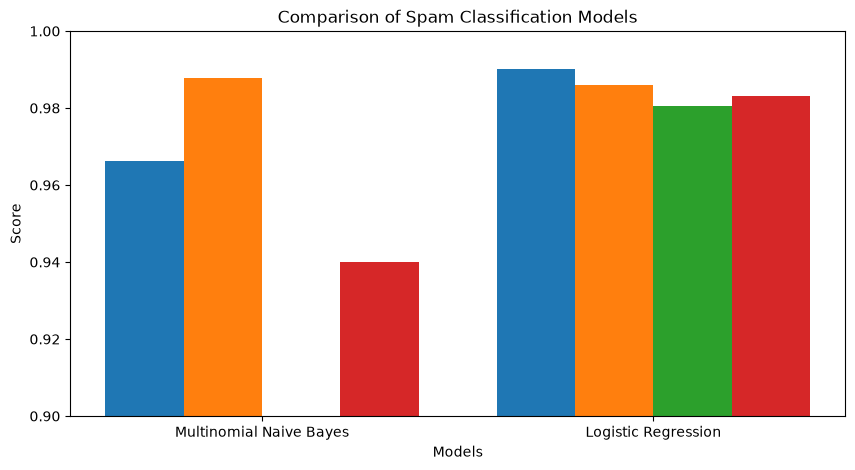

In [74]:
import matplotlib.pyplot as plt
import numpy as np

models = results["Model"]

accuracy = results["Accuracy"]
precision = results["Precision"]
recall = results["Recall"]
f1 = results["F1 Score"]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,5))

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall, width, label="Recall")
plt.bar(x + 1.5*width, f1, width, label="F1 Score")

plt.xticks(x, models)

plt.title("Comparison of Spam Classification Models")
plt.xlabel("Models")
plt.ylabel("Score")

plt.ylim(0.9, 1.0)

plt.legend()

plt.show()

In [75]:
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF object
tfidf = TfidfVectorizer()

# Fit on training data
X_train_tfidf = tfidf.fit_transform(X_train_clean)

# Transform test data
X_test_tfidf = tfidf.transform(X_test_clean)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4841, 142729)
(1211, 142729)


In [76]:
from sklearn.linear_model import LogisticRegression

lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)

lr_tfidf.fit(X_train_tfidf, y_train)

y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

In [77]:
from sklearn.naive_bayes import MultinomialNB

nb_tfidf = MultinomialNB()

nb_tfidf.fit(X_train_tfidf, y_train)

y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

In [78]:
import pandas as pd

comparison = pd.DataFrame({
    "Model":[
        "Naive Bayes (Count)",
        "Logistic Regression (Count)",
        "Naive Bayes (TF-IDF)",
        "Logistic Regression (TF-IDF)"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,y_pred_logistic),
        accuracy_score(y_test,y_pred_nb_tfidf),
        accuracy_score(y_test,y_pred_lr_tfidf)
    ],

    "Precision":[
        precision_score(y_test,y_pred),
        precision_score(y_test,y_pred_logistic),
        precision_score(y_test,y_pred_nb_tfidf),
        precision_score(y_test,y_pred_lr_tfidf)
    ],

    "Recall":[
        recall_score(y_test,y_pred),
        recall_score(y_test,y_pred_logistic),
        recall_score(y_test,y_pred_nb_tfidf),
        recall_score(y_test,y_pred_lr_tfidf)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred),
        f1_score(y_test,y_pred_logistic),
        f1_score(y_test,y_pred_nb_tfidf),
        f1_score(y_test,y_pred_lr_tfidf)
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes (Count),0.9661,0.9877,0.8966,0.9400
1,Logistic Regression (Count),0.9901,0.9860,0.9804,0.9832
2,Naive Bayes (TF-IDF),0.8613,0.9398,0.5670,0.7073
3,Logistic Regression (TF-IDF),0.9727,0.9765,0.9302,0.9528


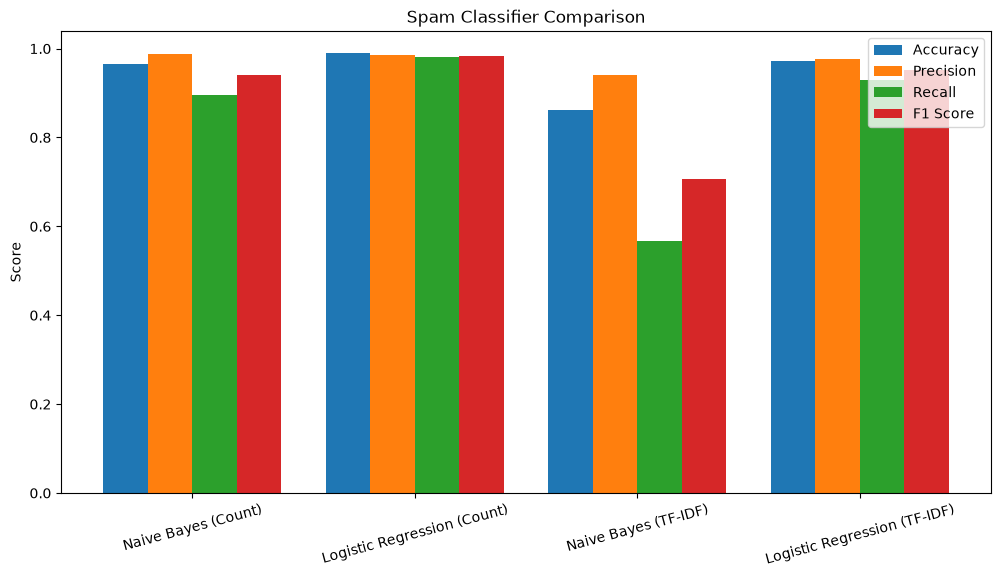

In [79]:
import matplotlib.pyplot as plt
import numpy as np

models = comparison["Model"]

accuracy = comparison["Accuracy"]
precision = comparison["Precision"]
recall = comparison["Recall"]
f1 = comparison["F1 Score"]

x = np.arange(len(models))

width = 0.2

plt.figure(figsize=(12,6))

plt.bar(x-1.5*width,accuracy,width,label="Accuracy")
plt.bar(x-0.5*width,precision,width,label="Precision")
plt.bar(x+0.5*width,recall,width,label="Recall")
plt.bar(x+1.5*width,f1,width,label="F1 Score")

plt.xticks(x,models,rotation=15)

plt.ylabel("Score")
plt.title("Spam Classifier Comparison")

plt.legend()

plt.show()

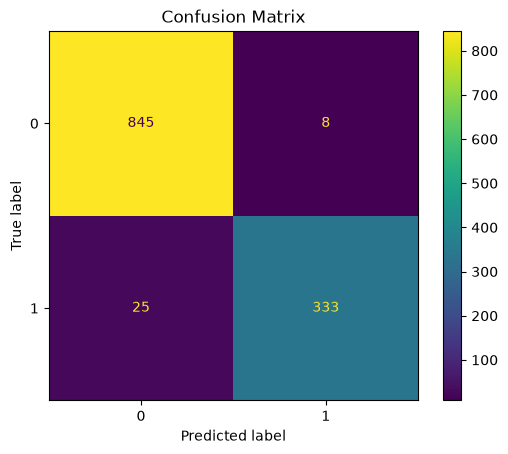

In [80]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr_tfidf
)

plt.title("Confusion Matrix")

plt.show()

In [81]:
def predict_email(email):

    cleaned = preprocess_email(email)

    vector = tfidf.transform([cleaned])

    prediction = lr_tfidf.predict(vector)

    if prediction[0] == 1:
        return "Spam"

    return "Ham"

In [82]:
email = """
Congratulations!

You have won $5000.

Click here now

https://abc.com
"""

print(predict_email(email))

Spam


In [85]:
# Import libraries
import joblib
from pathlib import Path

# Create the models directory path
MODELS_DIR = Path("../models")

# Create the folder if it doesn't exist
MODELS_DIR.mkdir(exist_ok=True)

# Save the trained Logistic Regression model
joblib.dump(
    lr_tfidf,
    MODELS_DIR / "spam_classifier.pkl"
)

# Save the TF-IDF vectorizer
joblib.dump(
    tfidf,
    MODELS_DIR / "tfidf_vectorizer.pkl"
)

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


In [86]:
import joblib
from pathlib import Path

MODELS_DIR = Path("../models")

# Load model
model = joblib.load(MODELS_DIR / "spam_classifier.pkl")

# Load vectorizer
vectorizer = joblib.load(MODELS_DIR / "tfidf_vectorizer.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!
